# libraries import

In [1]:
import keras
keras.utils.set_random_seed(3342)

import matplotlib.pyplot as plt
#from google.colab import files

import h5py
import numpy as np
import seaborn as sns
import os

2025-11-06 18:50:47.860643: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# plotting functions

In [2]:
# weights heatmap
def plot_weight_heatmap(weights_array, title):
    if not isinstance(weights_array, np.ndarray): return
    plot_data = weights_array
    ylabel = "Input / Characteristic"; xlabel = "Output / Neuron"
    if weights_array.ndim == 1:
        plot_data = weights_array.reshape(1, -1); ylabel = "Bias"
    elif weights_array.ndim > 2:
        print(f"Error for '{title}': array has {weights_array.ndim} dimensions.")
        return
    fig_height = np.clip(plot_data.shape[0] * 0.4, 6, 20)
    fig_width = np.clip(plot_data.shape[1] * 0.4, 8, 24)
    plt.figure(figsize=(fig_width, fig_height))
    show_annotations = (plot_data.size < 500)
    sns.heatmap(plot_data, annot=show_annotations, fmt=".2f", cmap="vlag", center=0)
    plt.title(f"Heatmap: {title}\nShape: {weights_array.shape} mean: {np.mean(weights_array)}", fontsize=16)
    plt.xlabel(xlabel, fontsize=12); plt.ylabel(ylabel, fontsize=12)

    plt.tight_layout()
    plt.show()

In [3]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='validation loss')
    plt.grid(True)

    plt.ylabel('loss')
    #plt.yscale('log')
    plt.xlabel('epoch')
    plt.title(title)

    plt.legend(['train', 'validation'], loc='upper right')
    plt.tight_layout()

    #plt.savefig(f"{title}.png")
    #files.download(f"{title}.png")

    plt.show()

In [4]:
def plot_accuracy(history, title):
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='validation accuracy')
    plt.grid(True)

    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.title(title)

    plt.legend(['train', 'validation'], loc='lower right')
    plt.tight_layout()

    #plt.savefig(f"{title}.png")
    #files.download(f"{title}.png")

    plt.show()

# Dataset import & normalization


In [2]:
# data loading
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# image shape
height = x_train[0].shape[0]
width = x_train[0].shape[1]

print()
print(f"image shape = {height}x{width}")


image shape = 32x32


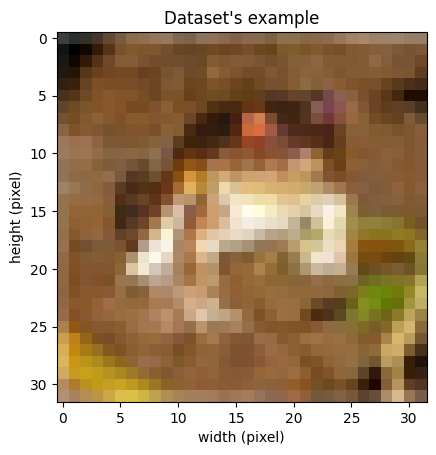

In [35]:
# image visualization
plt.figure()
plt.imshow(x_train[0], cmap=plt.cm.binary)

plt.title(f"Dataset's example")
plt.xlabel("width (pixel)")
plt.ylabel("height (pixel)")
plt.show()

# Target distribution

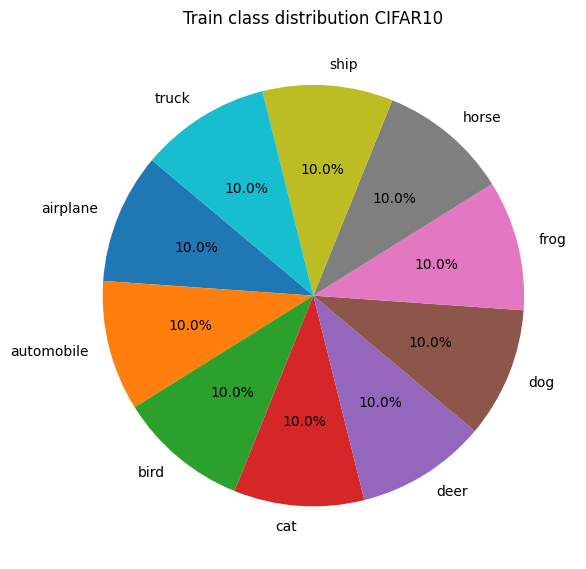

In [6]:
classes, counts = np.unique(y_train, return_counts=True)

class_names = ["airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"]

# class distribution plot
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=140)
plt.title("Train class distribution CIFAR10")

plt.tight_layout()
plt.show()

In [6]:
# data normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# target encoding
y_train_categorical = keras.utils.to_categorical(y_train, num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=10)

In [7]:
# data flattening
x_train = x_train.reshape(x_train.shape[0], height * width * 3)
x_test = x_test.reshape(x_test.shape[0], height * width * 3)

# First model creation

In [ ]:
first_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dense(4096, activation="relu", name='first_layer'),
        keras.layers.Dense(2048, activation='relu', name='second_layer'),
        keras.layers.Dense(1024, activation='relu', name='third_layer'),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer'),
        keras.layers.Dense(512, activation='relu', name='fifth_layer'),
        keras.layers.Dense(256, activation='relu', name='sixth_layer'),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

first_model.build()

first_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(first_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
first_model_history = first_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2)

## first model training results

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

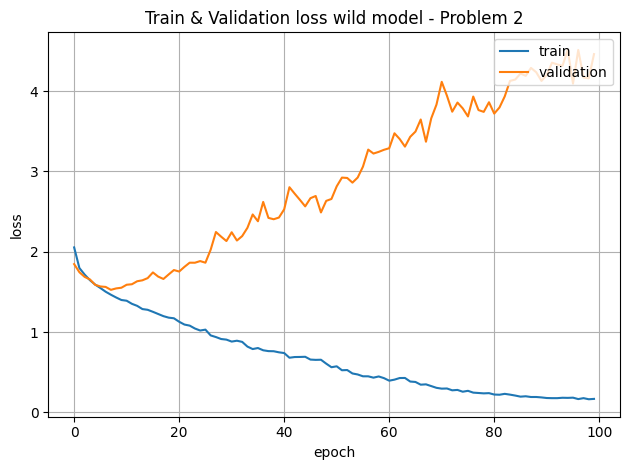

In [40]:
plot_loss(first_model_history, "Train & Validation loss wild model - Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

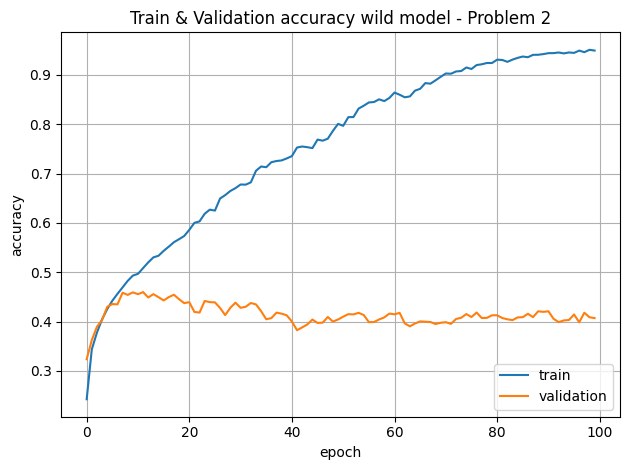

In [41]:
plot_accuracy(first_model_history, "Train & Validation accuracy wild model - Problem 2")

## weight plot

In [ ]:
# extract all_layers_weights' from weights.h5)
filename = 'problem2.weights.h5'
all_layers_weights = []
try:
    with h5py.File(filename, 'r') as f:
        layer_group_names = list(f.keys())
        for layer_name in layer_group_names:
            if 'optimizer' in layer_name.lower() or 'vars' in layer_name.lower():
                continue
            layer_group = f[layer_name]
            current_layer_weights = []
            def collect_datasets_from_group(name, obj):
                if isinstance(obj, h5py.Dataset):
                    weights_array = np.array(obj)
                    current_layer_weights.append(weights_array)
            if isinstance(layer_group, h5py.Group):
                layer_group.visititems(collect_datasets_from_group)
            if current_layer_weights:
                all_layers_weights.append(current_layer_weights)
except IOError:
    print(f"Error: File '{filename}' not found.")
except Exception as e:
    print(f"Error: {e}")


# show all heatmap of each layer without plotting bias heatmap
if all_layers_weights:
    print("\n--- heatmaps generation ---")

    for i in range(len(all_layers_weights)):
        layer_weights_list = all_layers_weights[i]

        for j, weights in enumerate(layer_weights_list):

            # bias filter
            if weights.ndim == 1:
                continue

            # plot info update
            plot_title = f"Layer {i} - Weights set {j} (Kernel)"

            plot_weight_heatmap(
                weights_array=weights,
                title=plot_title,
            )

else:
    print("\n'all_layers_weights' is empty no heatmaps generation")

print("\nCompleted.")

# first improved model

In [ ]:
second_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l1_l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(2048, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer', kernel_regularizer=keras.regularizers.l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fifth_layer', kernel_regularizer=keras.regularizers.l1_l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(512, activation='relu', name='sixth_layer', kernel_regularizer=keras.regularizers.l1_l2()),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256, activation='relu', name='seventh_layer', kernel_regularizer=keras.regularizers.l1_l2()),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

second_model.build()

second_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(second_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
second_model_history = second_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

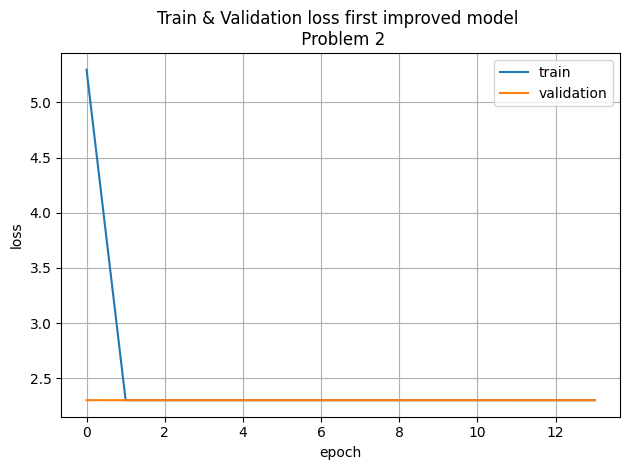

In [45]:
plot_loss(second_model_history, "Train & Validation loss first improved model \n Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

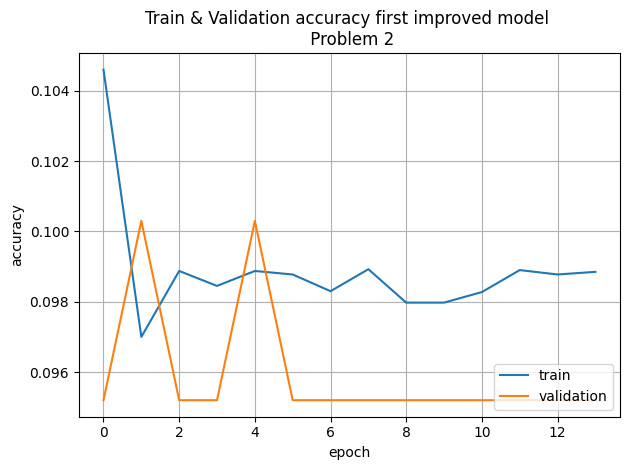

In [46]:
plot_accuracy(second_model_history, "Train & Validation accuracy first improved model \n Problem 2")

In [ ]:
# extract weights from second_model
second_model_weights = []
for layer in second_model.layers:
    if layer.get_weights():
        second_model_weights.append(layer.get_weights())

# show all heatmap of each layer without plotting bias heatmap
if second_model_weights:
    print("\n--- heatmaps generation ---")

    for i in range(len(second_model_weights)):
        layer_weights_list = second_model_weights[i]

        for j, weights in enumerate(layer_weights_list):

            # bias filter
            if weights.ndim == 1:
                continue

            # plot info update
            plot_title = f"Second Model - Layer {i} - Weights set {j} (Kernel)"

            plot_weight_heatmap(
                weights_array=weights,
                title=plot_title,
            )

else:
    print("\n'second_model_weights' is empty no heatmaps generation")

print("\nCompleted.")

# second improved model

In [ ]:
alpha_l2 = 0.0001
alpha_l1l2 = 0.00001

third_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(2048, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fifth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(512, activation='relu', name='sixth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256, activation='relu', name='seventh_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

third_model.build()

third_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(third_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
third_model_history = third_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

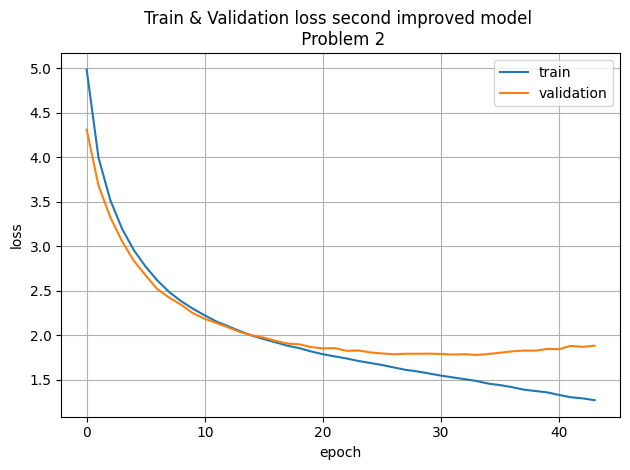

In [50]:
plot_loss(third_model_history, "Train & Validation loss second improved model \n Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

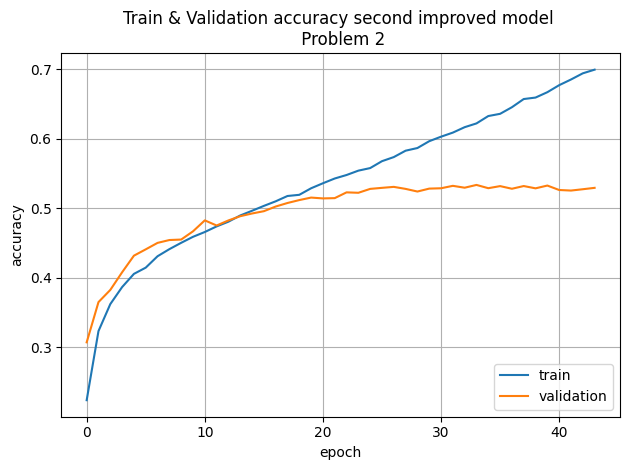

In [51]:
plot_accuracy(third_model_history, "Train & Validation accuracy second improved model \n Problem 2")

# third improved model

In [ ]:
alpha_l2 = 0.0001
alpha_l1l2 = 0.00001

fourth_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(2048, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer', kernel_regularizer=keras.regularizers.l2(alpha_l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fifth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(512, activation='relu', name='sixth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256, activation='relu', name='seventh_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

fourth_model.build()

fourth_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(fourth_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
fourth_model_history = fourth_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

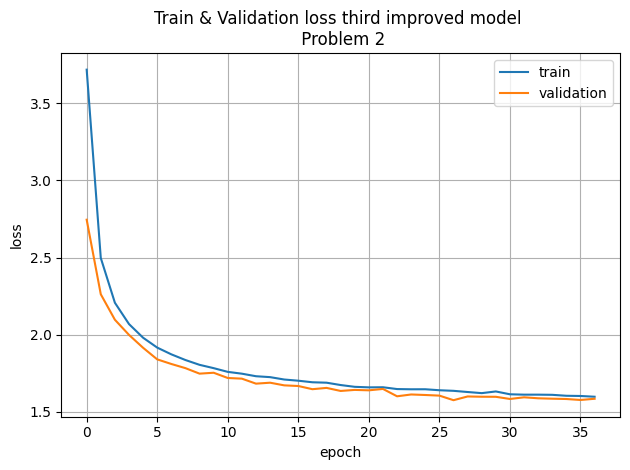

In [54]:
plot_loss(fourth_model_history, "Train & Validation loss third improved model \n Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

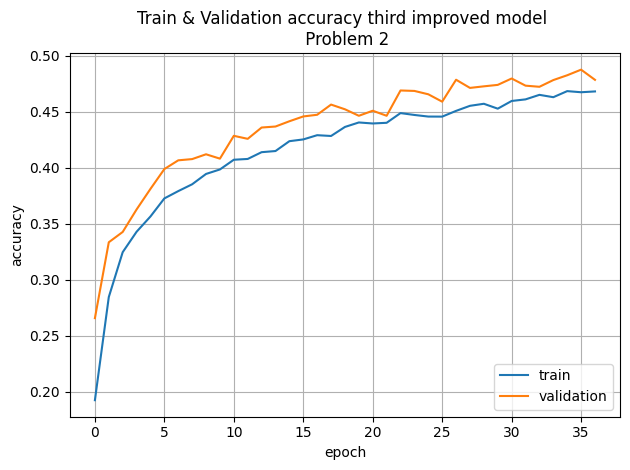

In [55]:
plot_accuracy(fourth_model_history, "Train & Validation accuracy third improved model \n Problem 2")

In [ ]:
# extract weights from second_model
fourth_model_weights = []
for layer in fourth_model.layers:
    if layer.get_weights():
        fourth_model_weights.append(layer.get_weights())

# show all heatmap of each layer without plotting bias heatmap
if fourth_model_weights:
    print("\n--- heatmaps generation ---")

    for i in range(len(fourth_model_weights)):
        layer_weights_list = fourth_model_weights[i]

        for j, weights in enumerate(layer_weights_list):

            # bias filter
            if weights.ndim == 1:
                continue

            # plot info update
            plot_title = f"Fourth Model - Layer {i} - Weights set {j} (Kernel)"

            plot_weight_heatmap(
                weights_array=weights,
                title=plot_title,
            )

else:
    print("\n'fourth_model_weights' is empty no heatmaps generation")

print("\nCompleted.")

# fourth improved model

In [ ]:
alpha_l2 = 0.0001
alpha_l1l2 = 1e-7

fifth_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(4096, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(2048, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fifth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(512, activation='relu', name='sixth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256, activation='relu', name='seventh_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

fifth_model.build()

fifth_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(fifth_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
fifth_model_history = fifth_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

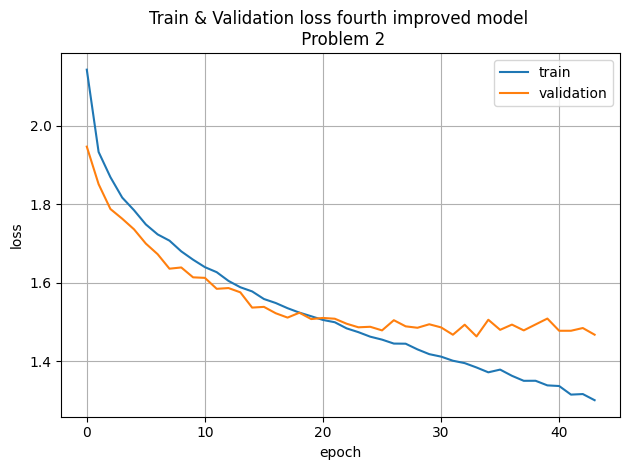

In [17]:
plot_loss(fifth_model_history, "Train & Validation loss fourth improved model \n Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

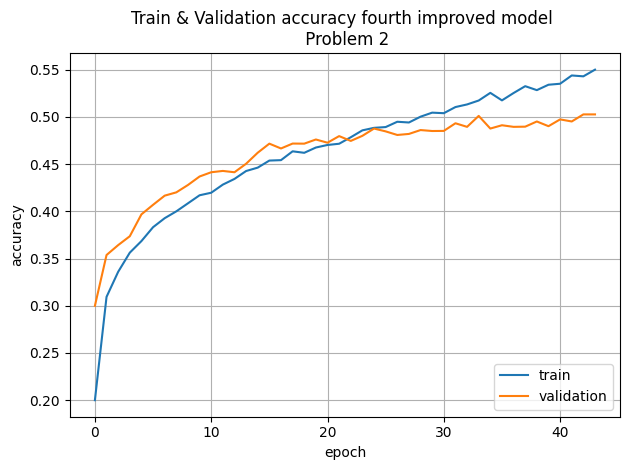

In [18]:
plot_accuracy(fifth_model_history, "Train & Validation accuracy fourth improved model \n Problem 2")

# fifth improved model

In [ ]:
alpha_l2 = 0.0001
alpha_l1l2 = 1e-7

sixth_model = keras.Sequential(
    [
        keras.Input(shape=(3072,)),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(4096, activation="relu", name='first_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(4096, activation='relu', name='second_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(2048, activation='relu', name='third_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1024, activation='relu', name='fourth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1024, activation='relu', name='fifth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(512, activation='relu', name='sixth_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(256, activation='relu', name='seventh_layer', kernel_regularizer=keras.regularizers.l1_l2(alpha_l1l2)),
        keras.layers.Dense(10, activation='softmax', name='output_layer')
    ]
)

sixth_model.build()

sixth_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

keras.utils.plot_model(sixth_model,
                       dpi=80,
                       show_shapes=True,
                       show_layer_names=True)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)
sixth_model_history = sixth_model.fit(x_train, y_train_categorical, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

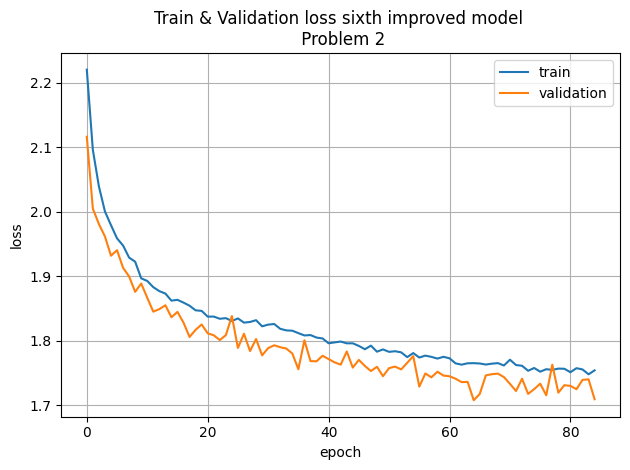

In [39]:
plot_loss(sixth_model_history, "Train & Validation loss sixth improved model \n Problem 2")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

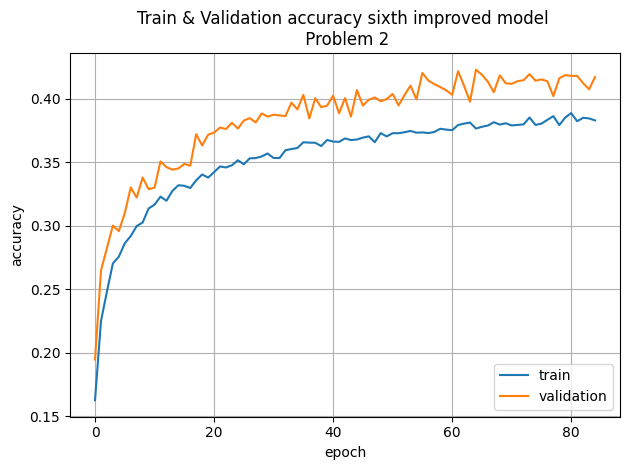

In [40]:
plot_accuracy(sixth_model_history, "Train & Validation accuracy sixth improved model \n Problem 2")